# 바나프레소 입지 추천 분석
+ rule-based로 점수화하여 추천할 계획
+ 왜냐하면, 데이터가 부족함.
    - 영업 중인 바나프레소 59개(이 중 3년 이상은 10개), 폐업된 바나프레소 4개 <br>
        ∴ 어떤 모델도 돌리기에는 설명력이 너무 부족

In [21]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [22]:
import numpy as np
import pandas as pd
import re
import geopandas as gpd
from scipy.spatial import cKDTree
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib, matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import seaborn as sns
import folium
from folium.plugins import MarkerCluster


In [23]:
system = platform.system()

if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 1. 바나프레소 정보만 가져오기

1. 서울 카페 정보 중 **바나프레소** 인 것만 필터링.
2. apv_date가 3년 전 이상인 것만 필터링 why? 3년 이상 영업 가게를 성공 가게라고 판단했기 때문.

In [24]:
# 카페 데이터 가져오기
cafe = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/cafe.csv")
cafe.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555


In [25]:
# 바나프레소만 추출
bana_df = cafe[cafe['nm'].str.contains(r"바나프레소|banapresso", case=False, na=False)].copy()
print(len(bana_df))

# 날짜 변환
bana_df['apv_date'] = pd.to_datetime(bana_df['apv_date'], errors='coerce')

# 오늘 기준 3년 이상(= 3년 전 이하) 된 매장만
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=3)
bana_df["success"] = (bana_df["apv_date"] <= cutoff).astype(int)

# 확인
bana_df["success"].value_counts()

59


success
0    49
1    10
Name: count, dtype: int64

# 2. 수요 점수 변수
2024년 4분기부터 2025년 3분기 까지의 데이터 사용 
<br>
- 2-1. 유동 인구_점심: tmzon_11_14_flpop_co
- 2-2. 유동 인구_저녁: tmzon_17_21_flpop_co
- 2-3. 유동 인구_기타 시간 평균: tmzon_00_06_flpop_co, tmzon_06_11_flpop_co, tmzon_14_17_flpop_co, tmzon_21_24_flpop_co

In [26]:
print(bana_df["flpop_type"].unique())

['T' 'A']


- 성공한 카페는 flpop_t.csv 만으로도 유동인구 값 가져올 수 있음

In [29]:
# 유동인구 데이터 불러오기
flpop_t = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/flpop_t.csv")
flpop_a = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/flpop_a.csv")
print(flpop_t.columns)
print(flpop_a.columns)

Index(['stdr_yyqu_cd', 'trdar_se_cd_nm', 'trdar_cd', 'trdar_cd_nm',
       'tot_flpop_co', 'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co',
       'agrde_20_flpop_co', 'agrde_30_flpop_co', 'agrde_40_flpop_co',
       'agrde_50_flpop_co', 'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',
       'tues_flpop_co', 'wed_flpop_co', 'thur_flpop_co', 'fri_flpop_co',
       'sat_flpop_co', 'sun_flpop_co'],
      dtype='object')
Index(['stdr_yyqu_cd', 'adstrd_cd', 'adstrd_cd_nm', 'tot_flpop_co',
       'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co', 'agrde_20_flpop_co',
       'agrde_30_flpop_co', 'agrde_40_flpop_co', 'agrde_50_flpop_co',
       'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co

In [30]:
# 최근 4개 분기 추출
recent_quarters = sorted(flpop_t["stdr_yyqu_cd"].unique())[-4:]

# 필터링
flpop_t = flpop_t[flpop_t["stdr_yyqu_cd"].isin(recent_quarters)]
flpop_a = flpop_a[flpop_a["stdr_yyqu_cd"].isin(recent_quarters)]

In [31]:
# 중복(이상치) 확인
print(flpop_t[["stdr_yyqu_cd","trdar_cd"]].duplicated().sum())
print(flpop_a[["stdr_yyqu_cd","adstrd_cd"]].duplicated().sum())

0
0


In [32]:
# 분기 평균 집계
agg_cols = ["tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co",
            "tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co",
            "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]

flpop_t_agg = flpop_t.groupby("trdar_cd")[agg_cols].mean().reset_index()
flpop_a_agg = flpop_a.groupby("adstrd_cd")[agg_cols].mean().reset_index()

# etc 평균 계산
etc_cols = ["tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co", "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]
flpop_t_agg["flpop_etc"] = flpop_t_agg[etc_cols].mean(axis=1)
flpop_a_agg["flpop_etc"] = flpop_a_agg[etc_cols].mean(axis=1)

In [33]:
flpop_a_agg

,adstrd_cd,tmzon_11_14_flpop_co,tmzon_17_21_flpop_co,tmzon_00_06_flpop_co,tmzon_06_11_flpop_co,tmzon_14_17_flpop_co,tmzon_21_24_flpop_co,flpop_etc
0,11110515,500612.50,578186.75,764008.75,695880.25,496522.75,396395.75,5.882019e+05
1,11110530,785096.00,800972.75,462503.75,833639.75,795807.75,329475.00,6.053566e+05
2,11110540,189512.25,162304.25,158158.75,197656.50,187852.75,80772.75,1.561102e+05
3,11110550,113146.00,138369.00,233406.50,193447.25,109598.75,114718.50,1.627928e+05
4,11110560,95763.00,138732.75,263526.50,190671.50,94246.75,123374.00,1.679547e+05
...,...,...,...,...,...,...,...,...
420,11740650,920444.50,1377540.25,2302846.00,1689404.25,935937.50,1107762.25,1.508988e+06
421,11740660,762420.50,1072372.75,1852932.25,1368657.50,746946.00,885058.75,1.213399e+06
422,11740685,2099678.75,2972146.50,4900869.50,3691237.75,2090460.00,2401415.00,3.270996e+06
423,11740690,2754.75,3662.25,6182.75,4974.50,2686.75,2983.00,4.206750e+03


In [34]:
# flpop_type T 매핑
tr_mask = bana_df["flpop_type"] == "T"
tr_merged = bana_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = bana_df["flpop_type"] == "A"
ad_merged = bana_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
bana_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(bana_df.shape)
bana_df.head()

(59, 15)


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250


In [35]:
len(bana_df)

59

    2-4. 학교 수
    2-5. 지식산업센터 수
    2-6. 병원 수 
    2-7. 학원 수
    2-8. 체육도장업 수 

In [36]:
academy = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/academy_df.csv")
gym = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/gym_df.csv")
hospital = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/hospital_df.csv")
physical = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/physical_df.csv")
school = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/school.csv")
center = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/industry_center.csv")
print(academy.columns)
print(gym.columns)
print(hospital.columns)
print(physical.columns)
print(school.columns)
print(center.columns)

Index(['idx', 'nm', 'addr', 'lat', 'lng'], dtype='object')
Index(['idx', 'dtlstatenm', 'addr', 'nm', 'type', 'lat', 'lng'], dtype='object')
Index(['idx', 'dtlstatenm', 'nm', 'type', 'addr', 'lat', 'lng'], dtype='object')
Index(['idx', 'dtlstatenm', 'addr', 'type', 'nm', 'lat', 'lng'], dtype='object')
Index(['idx', 'nm', 'addr', 'type', 'lat', 'lng'], dtype='object')
Index(['nm', 'type', 'addr', 'lat', 'lng'], dtype='object')


In [37]:
# academy 에 type 칼럼이 없어서 추가
academy['type'] = '학원'
academy.head()

,idx,nm,addr,lat,lng,type
0,1,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993,학원
1,2,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031,학원
2,3,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
3,4,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
4,5,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945,학원


In [38]:
# 하나의 데이터프레임으로 만들기
dfs = [academy, gym, hospital, physical, school, center]

need_cols = ["type", "nm", "addr", "lat", "lng"]

# 각 df에서 필요한 컬럼만 추출(없는 컬럼은 NaN으로 생성)
picked = [d.reindex(columns=need_cols) for d in dfs]

# 세로로 합치기
buildings_df = pd.concat(picked, ignore_index=True)

buildings_df.head()

,type,nm,addr,lat,lng
0,학원,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993
1,학원,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031
2,학원,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
3,학원,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
4,학원,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945


In [39]:
buildings_df['type'].unique()

array(['학원', '병원', '학교', '지식산업센터'], dtype=object)

In [40]:
# 위경도 → 미터 단위 평면 좌표 변환 스케일
SCALE_LAT = 111_000        # 위도 1도 ≈ 111km
SCALE_LNG = 88_800         # 경도 1도 ≈ 88.8km (서울 기준)

# type 매핑
type_map = {
    "학원": "cnt_academy",
    "병원": "cnt_hospital",
    "학교": "cnt_school",
    "지식산업센터": "cnt_company"
}

# ── cKDTree 기반 반경 내 개수 계산 (벡터화) ──
def count_nearby_kdtree(query_lats, query_lngs, ref_df, radius_m):
    """query 좌표 배열 기준 ref_df 내 radius_m 이내 개수를 배열로 반환"""
    ref = np.column_stack([
        ref_df['lat'].values * SCALE_LAT,
        ref_df['lng'].values * SCALE_LNG
    ])
    tgt = np.column_stack([
        np.asarray(query_lats) * SCALE_LAT,
        np.asarray(query_lngs) * SCALE_LNG
    ])
    return cKDTree(ref).query_ball_point(tgt, r=radius_m, return_length=True)

# ── cKDTree 기반 최소 거리 계산 (벡터화) ──
def min_dist_kdtree(query_lats, query_lngs, ref_df):
    """query 좌표 배열 기준 ref_df까지 최소 거리(m) 배열 반환"""
    ref = np.column_stack([
        ref_df['lat'].values * SCALE_LAT,
        ref_df['lng'].values * SCALE_LNG
    ])
    tgt = np.column_stack([
        np.asarray(query_lats) * SCALE_LAT,
        np.asarray(query_lngs) * SCALE_LNG
    ])
    dist, _ = cKDTree(ref).query(tgt, k=1)
    return dist

# ── bana_df: 주변 시설 개수 ──
la, ln = bana_df['lat'].values, bana_df['lng'].values

for btype, col in type_map.items():
    sub = buildings_df[buildings_df['type'] == btype].dropna(subset=['lat','lng'])
    bana_df[col] = count_nearby_kdtree(la, ln, sub, 300)

print('bana_df 주변 시설 피처 생성 완료')
bana_df.head()


bana_df 주변 시설 피처 생성 완료


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125,0,1,0,0
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625,0,0,0,0
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250,0,1,0,0
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375,0,0,0,0
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250,1,2,0,0


# 3. 접근성 점수 변수
    3-1. 지하철역 최소 거리
    3-2. 버스정류장 최소 거리
    3-3. 대로변 여부
    3-4. 횡단보도 수
    3-5. 층수

In [42]:
bus_stop = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/bus_stop.csv")
station = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/station.csv")
crosswalk = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/crosswalk.csv")
road = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/road.csv")

print(bus_stop.columns)
print(station.columns)
print(crosswalk.columns)
print(road.columns)

Index(['bus_stop_id', 'bus_stop_nm', 'lng', 'lat', 'type'], dtype='object')
Index(['addr', 'type', 'lat', 'lng'], dtype='object')
Index(['lng', 'lat', 'sigungu', 'emd', 'type'], dtype='object')
Index(['road_address', 'lng', 'lat', 'type'], dtype='object')


In [43]:
# ── bana_df: 접근성 피처 (cKDTree 벡터화) ──
la, ln = bana_df['lat'].values, bana_df['lng'].values

bana_df['dist_station']  = min_dist_kdtree(la, ln, station.dropna(subset=['lat','lng']))
bana_df['dist_bus_stop'] = min_dist_kdtree(la, ln, bus_stop.dropna(subset=['lat','lng']))
bana_df['cnt_crosswalk'] = count_nearby_kdtree(la, ln, crosswalk.dropna(subset=['lat','lng']), 300)
bana_df['is_road']       = (count_nearby_kdtree(la, ln, road.dropna(subset=['lat','lng']), 50) > 0).astype(int)

print('bana_df 접근성 피처 생성 완료')
bana_df[['dist_station','dist_bus_stop','cnt_crosswalk','is_road']].describe()


bana_df 접근성 피처 생성 완료


,dist_station,dist_bus_stop,cnt_crosswalk,is_road
count,59.000000,59.000000,59.000000,59.000000
mean,425.289856,85.723403,20.847458,0.220339
std,353.629015,54.867250,12.451026,0.418033
min,39.185192,16.667140,2.000000,0.000000
25%,187.693862,51.373841,12.000000,0.000000
50%,331.569029,68.183127,18.000000,0.000000
75%,580.372361,110.498514,27.000000,0.000000
max,1486.002053,246.114969,58.000000,1.000000


In [44]:
print(bana_df["floor"].isna().sum())
print(bana_df["floor"].value_counts().sort_index())

0
floor
-1.0     5
 1.0    54
Name: count, dtype: int64


In [45]:
# 1층 만점, 멀어질수록 감점
# 지하도 고려 (지하 = 음수)
def floor_score(floor):
    if floor == 1:
        return 1.0
    else:
        return max(1 - abs(floor - 1) * 0.2, 0) # 층수마다 0.2점씩 감점

bana_df["floor_score"] = bana_df["floor"].apply(floor_score)

# 4. 경쟁사 비교 점수 변수

In [46]:
cafe_nm = cafe['nm']
cafe_nm = cafe_nm.to_list()
cafe_nm

['베레베레',
 '덕수궁전통차전문',
 '엘빠소',
 '씨애틀즈베스트커피대사관점',
 '본솔카페',
 '링고요고',
 '토넷트커피숍',
 '썬휴게실',
 '네스카페',
 '루비콘플러스',
 '구스토',
 '아름다운고궁',
 '피카디리망고 일리',
 '소그노스에스프레소',
 '노모토커피',
 '주)키커피코리아',
 '강남커피숍',
 '캔모아',
 '북카페내서재',
 '플로리안',
 'BABIANA(바비아나)',
 '숭실대생협 아름다운세상',
 '보보스',
 '에스프레소인뉴욕',
 '할리스커피(Hollys Coffee)',
 '제일상회',
 '국립고궁박물관 뮤지엄숍',
 '모드뜨레',
 '카페돌로미티',
 '카페하임',
 '미래월드',
 '커피501(coffee501)',
 '메리메이트(MerryMate)',
 '귀천',
 '탐앤탐스노원점',
 '커피투어(Coffee Tour)',
 '쿠벅양평점',
 '세리커피(Coffee)',
 '테라 스위트(Terra sweet)본점',
 '물커피(Mool Coffee)',
 '세븐일레븐(서울시립대점)',
 '#11(Sharp eleven)',
 '커피보노',
 'ATM(에이티엠)',
 '미르엠(MIRM)',
 '토프레소 태평로점',
 'POLE243',
 'Meister haus',
 '빈스빈스',
 '이디야커피',
 '소풍',
 '다동커피집',
 '파나마',
 '동네커피',
 '영화에 빠진 커피',
 '두루',
 '니들 북',
 '헤이리커피공장103이촌점',
 '퓨얼리데카던트',
 '이디야올림픽공원점',
 '카페베네 종로5가점',
 '이디야 서대문점',
 '남산커피집',
 '보티',
 '커피데이',
 '아산엠 매점',
 '까사안띠구아',
 '커피홀릭',
 '카페깔리아리',
 '파반커피',
 '카페나루',
 '카페라비',
 '투미',
 '호텔디아망',
 '빈스커피',
 '투썸플레이스',
 '야노아',
 'An.s coffee',
 '슐레스',
 '알엔비스커피(RNBS COFFEE)',
 '아임빈',
 '바오밥나무 여성미래센

In [47]:
# 1) 이름 정규화 함수
def norm(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[\s\.\,\-\(\)\[\]\/_]", "", s)  # 공백/기호 제거
    return s

# 2) 브랜드 키워드(필요시 추가/수정)
LOW_PATTERNS = [
    "메가엠지씨", "메가mgc", "메가커피",
    "빽다방",
    "컴포즈", "compose",
    "더벤티", "theventi",
    "매머드", "mammoth",
    "텐퍼센트", "tenpercent",
    "커피베이",
    "우지커피", "oozy",
    "백억커피",
    "벤티프레소", "ventipresso",
]

HIGH_PATTERNS = [
    "스타벅스", "starbucks",
    "투썸", "twosome",
    "폴바셋", "paulbassett",
    "커피빈", "coffeebean",
    "할리스", "hollys",
    "아티제", "artisee",
    "테라로사", "terarosa",
    "오설록", "osulloc",
]

BANA_PATTERNS = ["바나프레소", "banapresso"]

def contains_any(text, patterns):
    return any(p in text for p in patterns)

# 3) 분류 함수
def cafe_tier(name):
    x = norm(name)
    if contains_any(x, BANA_PATTERNS):
        return "banapresso"
    if contains_any(x, HIGH_PATTERNS):
        return "high"
    if contains_any(x, LOW_PATTERNS):
        return "low"
    return "etc"

# 4) 적용
cafe["detail"] = cafe["nm"].apply(cafe_tier)

# 확인
print(cafe["detail"].value_counts())
cafe.head()

detail
etc           11194
low            2209
high           1071
banapresso       59
Name: count, dtype: int64


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710,etc
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520,etc
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650,etc
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615,etc
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555,etc


In [48]:
print(bana_df.index[:5])
print(cafe[cafe["detail"] == "banapresso"].index[:5])

Index([0, 0, 1, 1, 2], dtype='int64')
Index([2244, 3057, 4087, 5626, 6067], dtype='int64')


In [49]:
# detail 매핑
detail_map = {
    'banapresso': 'cnt_banapresso',
    'high':       'cnt_high_cafe',
    'low':        'cnt_low_cafe',
    'etc':        'cnt_etc_cafe'
}

# ── bana_df: 경쟁 카페 개수 (cKDTree 벡터화) ──
la, ln = bana_df['lat'].values, bana_df['lng'].values

for grade, col in detail_map.items():
    sub = cafe[cafe['detail'] == grade].dropna(subset=['lat','lng'])
    bana_df[col] = count_nearby_kdtree(la, ln, sub, 300)

# 자기 자신(바나프레소) 보정: bana_df는 바나프레소 매장이므로 cnt_banapresso에서 1 차감
bana_df['cnt_banapresso'] = (bana_df['cnt_banapresso'] - 1).clip(lower=0)

# 인덱스 리셋
bana_df = bana_df.reset_index(drop=True)
print('bana_df 경쟁 카페 피처 생성 완료')
bana_df.head(2)


bana_df 경쟁 카페 피처 생성 완료


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,floor_score,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.4,37.501130,127.039099,T,3120197.0,...,0,224.999516,24.929958,8,0,1.0,0,6,6,27
1,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.7,37.654291,127.075304,A,NaN,...,0,749.930335,117.242118,18,0,1.0,0,0,1,2


In [50]:
# 인덱스 리셋
bana_df = bana_df.reset_index(drop=True)
bana_df.tail(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,floor_score,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
54,바나프레소 용산센트럴파크점,커피숍,2026-01-06,서울 용산구 서빙고로 17,1.0,40.53,37.526906,126.966566,T,3120041.0,...,0,334.581885,53.537258,36,1,1.0,0,4,9,30
55,바나프레소 강남역 신분당선점,커피숍,2026-01-08,서울 강남구 강남대로 302-2,-1.0,32.38,37.490350,127.031507,T,3120192.0,...,0,761.484860,93.921109,16,0,0.6,0,6,5,31
56,바나프레소 동부이촌점,커피숍,2026-01-12,서울 용산구 이촌로 248,1.0,45.75,37.519387,126.975026,T,3110078.0,...,0,367.707757,68.954464,3,0,1.0,0,1,1,6
57,바나프레소 동소문점,커피숍,2023-07-21,서울 성북구 아리랑로 15,1.0,60.00,37.594241,127.015930,T,3120072.0,...,0,175.949502,58.561910,18,0,1.0,0,4,5,26
58,바나프레소 압구정SLP점,커피숍,2026-02-24,서울 강남구 논현로163길 23,1.0,131.66,37.524037,127.026247,T,3120188.0,...,0,331.569029,173.315346,6,1,1.0,1,4,3,33


# 중간 저장(csv로 내보내기)

In [27]:
bana_df.to_csv("bana.csv", index=False, encoding="utf-8-sig")

# 5. 수요 + 접근성 + 경쟁사 점수

In [65]:
print(bana_df[["flpop_lunch", "flpop_dinner", "flpop_etc"]].isnull().sum())

flpop_lunch     0
flpop_dinner    0
flpop_etc       0
dtype: int64


### 분포(값) 확인

In [66]:
print(bana_df[bana_df["success"]==0]["apv_date"].describe())

count                     49
mean     2024-11-19 00:00:00
min      2023-03-24 00:00:00
25%      2024-02-21 00:00:00
50%      2025-01-06 00:00:00
75%      2025-09-11 00:00:00
max      2026-02-24 00:00:00
Name: apv_date, dtype: object


In [67]:
# crosswalk 3분위수 확인
print(bana_df["cnt_crosswalk"].describe())

count    59.000000
mean     20.847458
std      12.451026
min       2.000000
25%      12.000000
50%      18.000000
75%      27.000000
max      58.000000
Name: cnt_crosswalk, dtype: float64


In [68]:
bana_df = bana_df.reset_index(drop=True)

In [69]:
print(type(bana_df["cnt_banapresso"].mean()))
print(bana_df["cnt_banapresso"].mean())

<class 'numpy.float64'>
0.06779661016949153


In [70]:
bana_df['floor'].describe()

count    59.000000
mean      0.830508
std       0.561787
min      -1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: floor, dtype: float64

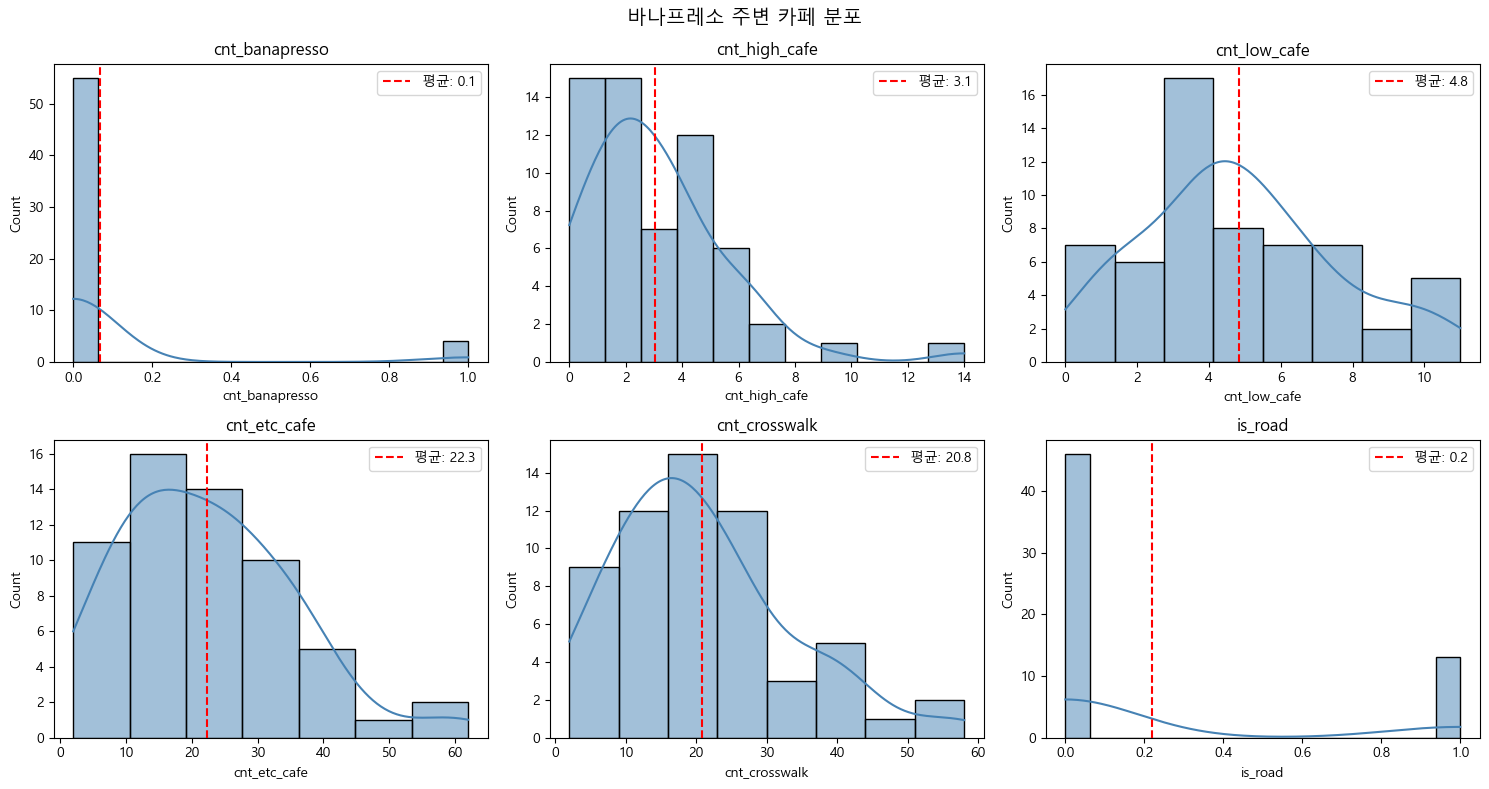

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("바나프레소 주변 카페 분포", fontsize=14)

cols = ["cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe", "cnt_crosswalk", "is_road"]

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(bana_df[col], kde=True, ax=ax, color="steelblue")
    ax.axvline(bana_df[col].mean(), color="red", linestyle="--", label=f"평균: {bana_df[col].mean():.1f}")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

- 고가 카페 (cnt_high_cafe) → 왼쪽 몰림 = 주변에 적은 게 일반적
    - 바나프레소는 고가 카페 없는 곳에 주로 입점
    - 하지만, 비즈니스 적으로 고가 카페가 많은 곳에 저가 카페가 있으면 경쟁력이 분명 있음.
    - 따라서, high better로 유지

- 저가 카페 (cnt_low_cafe) → 종모양, 평균 4.5
    - 딱히 방향성 없음.
    - lower_better 에 추가하기보다는 가중치 낮춤.
- 기타 카페 (cnt_etc_cafe) → 왼쪽 몰림
    - 많다는 것이 상권의 활성화 신호로도 볼 수 있고 아니면, 레드오션으로도 볼 수 있음.
    - 다만, 강남역은 이미 유동인구가 많은 곳. 상권의 활성화 신호는 유동인구로 확인.
    - 따라서, lower_better 로 두되, 가중치는 낮춤.

In [72]:
bana_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nm              59 non-null     object        
 1   type            59 non-null     object        
 2   apv_date        59 non-null     datetime64[ns]
 3   addr            59 non-null     object        
 4   floor           59 non-null     float64       
 5   sitearea        59 non-null     float64       
 6   lat             59 non-null     float64       
 7   lng             59 non-null     float64       
 8   flpop_type      59 non-null     object        
 9   trdar_cd        55 non-null     float64       
 10  adstrd_cd       59 non-null     int64         
 11  success         59 non-null     int64         
 12  flpop_lunch     59 non-null     float64       
 13  flpop_dinner    59 non-null     float64       
 14  flpop_etc       59 non-null     float64       
 15  cnt_acad

In [73]:
# ── STEP 0. 관심 변수 설정 ──
feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "floor_score",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# ── STEP 1. 프로파일 가중치 계산 ──
def get_profile_weight(apv_date):
    years = (pd.Timestamp.today() - apv_date).days / 365
    if years >= 3:
        return 3.0
    elif years >= 1:
        return 1.0
    else:
        return 0.5

bana_df["profile_weight"] = bana_df["apv_date"].apply(get_profile_weight)

# ── STEP 1.5 정규화 ──
lower_better = [
    "dist_station", "dist_bus_stop",  # 거리는 가까울수록
    "cnt_banapresso",                  # 자사 경쟁 적을수록
    "cnt_etc_cafe"                     # 기타 카페 적을수록
]
# cnt_low_cafe는 가중치만 낮게 유지 (0.01)

score_df = bana_df[feature_cols].copy()
for col in lower_better:
    score_df[col] = -score_df[col]  # 낮을수록 좋은 건 반전

scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(score_df),
    columns=feature_cols,
    index=bana_df.index
)

# ── STEP 2. 이상적 입지 프로파일 계산 (정규화된 값 기준) ──
ideal_profile = pd.Series({
    col: np.average(scaled[col], weights=bana_df["profile_weight"])
    for col in feature_cols
})

print("이상적 입지 프로파일:")
print(ideal_profile)

이상적 입지 프로파일:
flpop_lunch       0.249383
flpop_dinner      0.234394
flpop_etc         0.274983
dist_station      0.765029
dist_bus_stop     0.723672
cnt_crosswalk     0.335185
is_road           0.259259
floor_score       0.925926
cnt_academy       0.061111
cnt_hospital      0.174074
cnt_school        0.066667
cnt_company       0.067236
cnt_banapresso    0.955556
cnt_high_cafe     0.231217
cnt_low_cafe      0.441751
cnt_etc_cafe      0.634321
dtype: float64


### 프로파일 해석:
- is_road: 0.97 → 거의 모든 매장 대로변 → 사실상 필수 조건
- cnt_banapresso: 0.96 → 자사 경쟁 없는 게 일반적 → 중요
- dist_bus_stop: 0.72 → 버스정류장 가까운 편
- dist_station: 0.77 → 역도 가까운 편
- flpop: 0.23~0.27 → 중간 이하 (유동인구 엄청 높은 곳만은 아님)
- cnt_academy/school/company: 0.06~0.07 → 거의 없음 (주변시설 별로 안 중요할 수 있음)

In [74]:
# ── STEP 3. 가중치 설정 ──
weights = {
    # 유동인구 (38%) - 카페 매출 직결, 핵심
    "flpop_lunch":  0.14,
    "flpop_dinner": 0.14,
    "flpop_etc":    0.10,

    # 접근성 (37%) - 프로파일상 가장 일관된 패턴
    "dist_station":  0.08,  # 역 거리
    "dist_bus_stop": 0.07,  # 버스 거리
    "is_road":       0.09,  # 대로변 필수조건
    "cnt_crosswalk": 0.03,  # 보행 접근성
    "floor_score":   0.10,  # 층수 중요 (1층 선호 강함)

    # 주변 시설 (8%) - 프로파일상 거의 없음, 낮게
    "cnt_academy":  0.02,
    "cnt_hospital": 0.02,
    "cnt_school":   0.02,
    "cnt_company":  0.02,

    # 경쟁 강도 (17%) - 자사 경쟁 중심으로
    "cnt_banapresso": 0.08,  # 자사 경쟁 가장 중요
    "cnt_high_cafe":  0.05,  # 상권 소비력 지표
    "cnt_low_cafe":   0.02,  # 방향 불명확
    "cnt_etc_cafe":   0.02,  # 경쟁 신호, 낮게
}

print(sum(weights.values()))  # 1.0 확인

# ── STEP 4. 점수화 ──
def location_score(row, ideal, weights):
    score = 0
    for col in weights:
        if col == "is_road":
            # 1이면 만점, 0이면 0점
            score += (1.0 if row[col] >= 0.5 else 0.0) * weights[col]
        elif col == "cnt_crosswalk":
            # 최소값 2 넘으면 만점
            threshold = 2 / bana_df["cnt_crosswalk"].max()
            score += (1.0 if row[col] >= threshold else row[col] / threshold) * weights[col]
        elif col in ["flpop_lunch", "flpop_dinner", "flpop_etc"]:
            # ideal 이상이면 만점, 미만이면 비례 점수
            score += min(row[col] / ideal_profile[col], 1.0) * weights[col]
        else:
            score += (1 - abs(row[col] - ideal[col])) * weights[col]
    return score

bana_df["location_score"] = scaled.apply(
    lambda row: location_score(row, ideal_profile, weights), axis=1
)

# ── STEP 5. 검증 ──
print(bana_df.groupby("success")["location_score"].mean())
bana_df[["nm", "location_score", "success"]].sort_values("location_score", ascending=False)

1.0
success
0    0.709122
1    0.815473
Name: location_score, dtype: float64


,nm,location_score,success
9,바나프레소 양재이안점,0.958621,1
54,바나프레소 용산센트럴파크점,0.942575,0
2,바나프레소 신논현역점,0.935533,1
42,바나프레소 명동중앙우체국점,0.932282,1
45,바나프레소 신림역점,0.930026,0
46,바나프레소 군자역점,0.914626,0
8,바나프레소 홍대입구역사거리점,0.879024,1
29,바나프레소 서울성균관대점,0.876375,0
58,바나프레소 압구정SLP점,0.856707,0
57,바나프레소 동소문점,0.856115,0


In [75]:
# success=1 매장 순위 확인
bana_df["rank"] = bana_df["location_score"].rank(ascending=False, method='first').astype(int)
print(bana_df[bana_df["success"]==1][["nm", "location_score", "rank"]].sort_values("rank"))

                 nm  location_score  rank
9       바나프레소 양재이안점        0.958621     1
2       바나프레소 신논현역점        0.935533     3
42   바나프레소 명동중앙우체국점        0.932282     4
8   바나프레소 홍대입구역사거리점        0.879024     7
0       바나프레소 테헤란로점        0.855311    11
4       바나프레소 선릉공원점        0.843514    12
7        바나프레소 충무로점        0.813634    19
28    바나프레소 여의도파크원점        0.717054    32
40       바나프레소 양평역점        0.616852    46
52       바나프레소 마포역점        0.602907    47


In [76]:
print(bana_df.loc[[52, 40], ["nm", "flpop_lunch", "flpop_dinner", "dist_station", "cnt_etc_cafe"]])

            nm  flpop_lunch  flpop_dinner  dist_station  cnt_etc_cafe
52  바나프레소 마포역점    117808.75      141110.0     41.347885            14
40  바나프레소 양평역점     82196.00       68874.0     99.528289            15


# 6. 매물 점수화하기

In [77]:
listing_df = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/listing.csv")

# 원 → 만원, ㎡ → 평 변환 (이후 모든 셀에서 사용)
listing_df['deposit_만원']      = listing_df['deposit']      / 10_000
listing_df['monthly_rent_만원'] = listing_df['monthly_rent'] / 10_000
listing_df['size_평']           = (listing_df['size_m2'] / 3.3058).round(1)

print(f'전체 매물: {len(listing_df):,}건')
listing_df[['deposit_만원','monthly_rent_만원','size_평']].describe().round(1)


전체 매물: 1,319건


,deposit_만원,monthly_rent_만원,size_평
count,1319.0,1319.0,1319.0
mean,6140.2,487.0,39.3
std,8845.2,727.8,43.1
min,0.0,0.0,1.0
25%,2000.0,200.0,17.0
50%,4000.0,300.0,30.0
75%,6500.0,500.0,45.3
max,108000.0,9200.0,548.5


In [120]:
mask = (
    (listing_df["deposit"] == 0) &
    (listing_df["monthly_rent"] == 0)
)

print(f"제거 전: {len(listing_df)}행")
listing_df = listing_df[~mask].reset_index(drop=True)
print(f"제거 후: {len(listing_df)}행")

제거 전: 1316행
제거 후: 1309행


## 6-1. 수요점수 변수 생성

### 유동 인구 수 구하기

In [132]:
# flpop_type T 매핑
tr_mask = listing_df["flpop_type"] == "T"
tr_merged = listing_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = listing_df["flpop_type"] == "A"
ad_merged = listing_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
listing_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(listing_df.shape)
listing_df.head()

(1309, 54)


,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,rank,location_score_lr,success_prob,final_score,flpop_lunch,flpop_dinner,flpop_etc_y,flpop_lunch,flpop_dinner,flpop_etc
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,993,0.325824,0.421758,61.373241,265091.50,267129.00,233949.2500,265091.50,267129.00,233949.2500
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,150,0.461281,0.565102,78.267057,388874.50,478718.00,397097.6250,388874.50,478718.00,397097.6250
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,...,219,0.446111,0.557723,77.072024,388874.50,478718.00,397097.6250,388874.50,478718.00,397097.6250
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,...,1289,0.348274,0.276179,44.274384,54920.75,80063.75,58347.5000,54920.75,80063.75,58347.5000
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,...,176,0.523282,0.703935,81.837703,378147.00,391751.00,381067.3125,378147.00,391751.00,381067.3125


### 병원/학교/학원/산업센터 수 구하기

In [133]:
# ── listing_df: 주변 시설 개수 (cKDTree 벡터화) ──
la, ln = listing_df['lat'].values, listing_df['lng'].values

for btype, col in type_map.items():
    sub = buildings_df[buildings_df['type'] == btype].dropna(subset=['lat','lng'])
    listing_df[col] = count_nearby_kdtree(la, ln, sub, 300)

print('listing_df 주변 시설 피처 생성 완료')
listing_df.head()


listing_df 주변 시설 피처 생성 완료


,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,rank,location_score_lr,success_prob,final_score,flpop_lunch,flpop_dinner,flpop_etc_y,flpop_lunch,flpop_dinner,flpop_etc
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,993,0.325824,0.421758,61.373241,265091.50,267129.00,233949.2500,265091.50,267129.00,233949.2500
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,150,0.461281,0.565102,78.267057,388874.50,478718.00,397097.6250,388874.50,478718.00,397097.6250
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,...,219,0.446111,0.557723,77.072024,388874.50,478718.00,397097.6250,388874.50,478718.00,397097.6250
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,...,1289,0.348274,0.276179,44.274384,54920.75,80063.75,58347.5000,54920.75,80063.75,58347.5000
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,...,176,0.523282,0.703935,81.837703,378147.00,391751.00,381067.3125,378147.00,391751.00,381067.3125


## 6-2. 접근성 점수 변수 생성

In [134]:
# ── listing_df: 접근성 피처 (cKDTree 벡터화) ──
la, ln = listing_df['lat'].values, listing_df['lng'].values

listing_df['dist_station']  = min_dist_kdtree(la, ln, station.dropna(subset=['lat','lng']))
listing_df['dist_bus_stop'] = min_dist_kdtree(la, ln, bus_stop.dropna(subset=['lat','lng']))
listing_df['cnt_crosswalk'] = count_nearby_kdtree(la, ln, crosswalk.dropna(subset=['lat','lng']), 300)
listing_df['is_road']       = (count_nearby_kdtree(la, ln, road.dropna(subset=['lat','lng']), 50) > 0).astype(int)

print('listing_df 접근성 피처 생성 완료')
listing_df[['dist_station','dist_bus_stop','cnt_crosswalk','is_road']].describe()


listing_df 접근성 피처 생성 완료


,dist_station,dist_bus_stop,cnt_crosswalk,is_road
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,365.073038,133.178596,10.408709,0.417876
std,163.703333,76.053415,4.558349,0.493398
min,26.896393,9.490418,0.000000,0.000000
25%,223.784378,78.936641,7.000000,0.000000
50%,352.156541,117.869143,11.000000,0.000000
75%,485.048905,165.716399,14.000000,1.000000
max,763.128878,426.550238,22.000000,1.000000


In [135]:
def parse_floor(floor_str):
    if pd.isna(floor_str):
        return 1  # NaN이면 1층으로 처리
    floor_str = str(floor_str)
    if "반지하" in floor_str:
        return -0.5
    if "지하" in floor_str:

        num = re.search(r'\d+', floor_str)
        return -int(num.group()) if num else -1
    num = re.search(r'\d+', floor_str)
    return int(num.group()) if num else 1

# 층수 추출
listing_df["floor"] = listing_df["floor"].apply(parse_floor)

# 층수 점수화 1 점이면 만점, 멀어질수로 0.2 점씩 차감
listing_df["floor_score"] = listing_df["floor"].apply(floor_score)

print(listing_df[["floor", "floor_score"]].drop_duplicates().sort_values("floor"))

      floor  floor_score
154       0          0.8
1         1          1.0
2         2          0.8
6         3          0.6
0         4          0.4
14        5          0.2
27        6          0.0
7         7          0.0
213       8          0.0
561       9          0.0
26       10          0.0
46       11          0.0
110      12          0.0
421      13          0.0
467      14          0.0
1280     15          0.0
541      16          0.0
1281     17          0.0


## 6-3. 경쟁사 비교 점수 변수 생성

In [136]:
# ── listing_df: 경쟁 카페 개수 (cKDTree 벡터화) ──
la, ln = listing_df['lat'].values, listing_df['lng'].values

for grade, col in detail_map.items():
    sub = cafe[cafe['detail'] == grade].dropna(subset=['lat','lng'])
    listing_df[col] = count_nearby_kdtree(la, ln, sub, 300)

print('listing_df 경쟁 카페 피처 생성 완료')
listing_df.head(2)


listing_df 경쟁 카페 피처 생성 완료


,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,rank,location_score_lr,success_prob,final_score,flpop_lunch,flpop_dinner,flpop_etc_y,flpop_lunch,flpop_dinner,flpop_etc
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,993,0.325824,0.421758,61.373241,265091.5,267129.0,233949.250,265091.5,267129.0,233949.250
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,150,0.461281,0.565102,78.267057,388874.5,478718.0,397097.625,388874.5,478718.0,397097.625


## 6-4. 비용 리스크 점수 변수 생성

In [137]:
listing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   listing_id         1309 non-null   int64  
 1   addr               1309 non-null   object 
 2   lat                1309 non-null   float64
 3   lng                1309 non-null   float64
 4   business_type      1309 non-null   object 
 5   transaction_type   1309 non-null   object 
 6   sale_price         1309 non-null   int64  
 7   key_money          1309 non-null   int64  
 8   deposit            1309 non-null   int64  
 9   monthly_rent       1309 non-null   int64  
 10  maintenance_fee    1309 non-null   int64  
 11  size_m2            1309 non-null   float64
 12  floor              1309 non-null   int64  
 13  flpop_type         1309 non-null   object 
 14  trdar_cd           1309 non-null   int64  
 15  adstrd_cd          1309 non-null   int64  
 16  deposit_만원         1309 

In [138]:
listing_df.isna().sum()

listing_id           0
addr                 0
lat                  0
lng                  0
business_type        0
transaction_type     0
sale_price           0
key_money            0
deposit              0
monthly_rent         0
maintenance_fee      0
size_m2              0
floor                0
flpop_type           0
trdar_cd             0
adstrd_cd            0
deposit_만원           0
monthly_rent_만원      0
size_평               0
flpop_lunch          0
flpop_dinner         0
flpop_etc_x          0
cnt_academy          0
cnt_hospital         0
cnt_school           0
cnt_company          0
dist_station         0
dist_bus_stop        0
cnt_crosswalk        0
is_road              0
floor_score          0
cnt_banapresso       0
cnt_high_cafe        0
cnt_low_cafe         0
cnt_etc_cafe         0
actual_rent          0
rent_index           0
startup_cost         0
coverage             0
rent_score           0
capital_score        0
cost_score           0
location_score       0
recom_score

In [139]:
# 사용자 자본금 설정
CAPITAL = 120_000_000  # 1억 2천만원

# ── 1. 실질 월세 계산 ──
listing_df["actual_rent"] = listing_df["monthly_rent"] + listing_df["maintenance_fee"]

# ── 2. 행정동별 평균 실질 월세 계산 ──
dong_avg_rent = listing_df.groupby("adstrd_cd")["actual_rent"].mean()

# ── 3. 비용 리스크 세부 변수 계산 ──

# 1) 월세 지수 (실질 월세 ÷ 행정동 평균 실질 월세)
listing_df["rent_index"] = listing_df.apply(
    lambda row: row["actual_rent"] / dong_avg_rent.get(row["adstrd_cd"], dong_avg_rent.mean()),
    axis=1
)

# 2) 실제 필요 자본금 (창업비용 + 보증금 + 권리금)
listing_df["startup_cost"] = (
    (listing_df["size_m2"] / 33) * 8_370_000
    + listing_df["deposit"]
    + listing_df["key_money"]
)

# 3) 자본금 충당률
listing_df["coverage"] = (CAPITAL / listing_df["startup_cost"]).clip(upper=1.0)

# ── 4. 점수화 ──
# 월세 점수 (10점) - 전체 분포 기준 상대적 저렴함
rent_scaler = MinMaxScaler()
listing_df["rent_score"] = (1 - rent_scaler.fit_transform(
    listing_df[["rent_index"]]
)) * 10

# 자본금 충당 점수 (15점)
listing_df["capital_score"] = listing_df["coverage"] * 15.0

# 비용 리스크 점수 (25점)
listing_df["cost_score"] = listing_df["rent_score"] + listing_df["capital_score"]

# ── 5. 확인 ──
print(listing_df["rent_score"].describe())
print(listing_df["cost_score"].describe())
listing_df[["addr", "actual_rent", "rent_index", "rent_score", "capital_score", "cost_score"]].head()

count    1309.000000
mean        9.438439
std         0.791360
min         0.000000
25%         9.425287
50%         9.652386
75%         9.770115
max        10.000000
Name: rent_score, dtype: float64
count    1309.000000
mean       22.690025
std         3.901615
min         1.533339
25%        22.329225
50%        24.621356
75%        24.764747
max        24.943654
Name: cost_score, dtype: float64


,addr,actual_rent,rent_index,rent_score,capital_score,cost_score
0,서울특별시 강남구 논현동,2000000,0.401352,9.774617,15.000000,24.774617
1,서울특별시 서초구 잠원동,3000000,0.667326,9.625256,15.000000,24.625256
2,서울특별시 강남구 논현동,3000000,0.558229,9.686520,15.000000,24.686520
3,서울특별시 강남구 논현동,6700000,1.246711,9.299896,4.903472,14.203368
4,서울특별시 강남구 논현동,3700000,0.742500,9.583041,6.167552,15.750592


## 6-5. 최종 매물 추천 점수 계산

In [140]:
print([col for col in feature_cols if col not in listing_df.columns])

[]


In [142]:
print("fit 때 컬럼:", scaler.feature_names_in_.tolist())
print("transform 때 컬럼:", listing_score_df.columns.tolist())

fit 때 컬럼: ['flpop_lunch', 'flpop_dinner', 'flpop_etc', 'dist_station', 'dist_bus_stop', 'cnt_crosswalk', 'is_road', 'floor_score', 'cnt_academy', 'cnt_hospital', 'cnt_school', 'cnt_company', 'cnt_banapresso', 'cnt_high_cafe', 'cnt_low_cafe', 'cnt_etc_cafe']
transform 때 컬럼: ['flpop_lunch', 'flpop_lunch', 'flpop_lunch', 'flpop_dinner', 'flpop_dinner', 'flpop_dinner', 'flpop_etc', 'dist_station', 'dist_bus_stop', 'cnt_crosswalk', 'is_road', 'floor_score', 'cnt_academy', 'cnt_hospital', 'cnt_school', 'cnt_company', 'cnt_banapresso', 'cnt_high_cafe', 'cnt_low_cafe', 'cnt_etc_cafe']


In [143]:
# ── STEP 1. listing_df 정규화 (bana_df 기준 scaler 재사용) ──
feature_cols = list(dict.fromkeys(feature_cols))
listing_score_df = listing_df[feature_cols].copy()
for col in lower_better:
    listing_score_df[col] = -listing_score_df[col]

listing_scaled = pd.DataFrame(
    scaler.transform(listing_score_df),  # fit은 bana_df 기준, transform만
    columns=feature_cols,
    index=listing_df.index
)

# ── STEP 2. 입지 점수 계산 (0~1) ──
listing_df["location_score"] = listing_scaled.apply(
    lambda row: location_score(row, ideal_profile, weights), axis=1
)

# ── STEP 3. 최종 추천 점수 계산 (0~100) ──
listing_df["recom_score"] = listing_df["location_score"] * 75 + listing_df["cost_score"]

# ── STEP 4. 확인 ──
listing_df[["listing_id", "addr", "location_score", "rent_score", "capital_score", "cost_score", "recom_score"]]\
    .sort_values("recom_score", ascending=False)\
    .head(5)

ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [90]:
# 최종 순위
listing_df["rank"] = listing_df["recom_score"].rank(ascending=False, method='first').astype(int)

listing_df[["listing_id", "floor", "location_score", "cost_score", "recom_score", "rank"]]\
    .sort_values("rank").head(20)

,listing_id,floor,location_score,cost_score,recom_score,rank
243,808105,1.0,0.949310,24.722324,95.920541,1
329,881607,1.0,0.959166,23.974613,95.912049,2
327,882189,1.0,0.949310,24.682656,95.880873,3
466,891481,1.0,0.947261,24.769464,95.814037,4
664,921586,1.0,0.947261,24.769464,95.814037,5
416,473413,1.0,0.942140,24.644723,95.305224,6
668,921771,1.0,0.938696,24.885057,95.287258,7
608,908913,1.0,0.942690,24.487983,95.189735,8
1208,784426,1.0,0.939744,24.649948,95.130770,9
297,823072,1.0,0.933255,24.644723,94.638857,10


In [144]:
listing_df = listing_df.reset_index(drop=True)
listing_df.to_csv("listing_scored_rule.csv", index=False, encoding="utf-8-sig")

# 7. Logistic Regression

## Logistic Regression 선택 이유

학습 데이터가 59개로 매우 작기 때문에 과적합을 방지하고 모델 해석 가능성을 확보하기 위해 Logistic Regression을 사용하였다.

또한 Logistic Regression은 성공 확률을 직접 출력할 수 있어 매물 추천 시 확률 기반 ranking 모델로 활용하기 적합하다.

| 항목 | 내용 |
|------|------|
| X | feature_cols 16개 피처 (스케일링 후) |
| y | success (1=3년 이상 운영, 0=신규/실패) |
| 정규화 | L2 — 소표본 과적합 방지, C값으로 강도 조절 |


## 7.1 데이터 준비 및 스케일링

- bana_df + listing_df 통합 후 MinMaxScaling
- rule-based에서 정의된 `feature_cols`, `lower_better` 그대로 재사용
- bana_df, listing_df를 함께 fit해 동일한 스케일 공간에서 비교


In [105]:
# OS별 한글 폰트 설정
import platform
system = platform.system()
if system == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rc('axes', unicode_minus=False)


# listing_df에 floor_score 컬럼이 없으면 생성
if 'floor_score' not in listing_df.columns:
    listing_df['floor_score'] = listing_df['floor'].apply(floor_score)

# bana_df + listing_df 통합 스케일링
combined = pd.concat([
    bana_df[feature_cols],
    listing_df[feature_cols].fillna(0)
], ignore_index=True)

combined_input = combined.copy()
for col in lower_better:
    combined_input[col] = -combined_input[col]   # 낮을수록 좋은 피처 반전

scaler_all = MinMaxScaler()
combined_scaled = pd.DataFrame(
    scaler_all.fit_transform(combined_input),
    columns=feature_cols
)

n_bana = len(bana_df)
X_bana    = combined_scaled.iloc[:n_bana].values
X_listing = combined_scaled.iloc[n_bana:].values
y_bana    = bana_df['success'].values

print(f'학습 데이터: {n_bana}개  (성공: {y_bana.sum()}개, 실패: {(y_bana==0).sum()}개)')
print(f'예측 대상: {len(X_listing):,}개 매물')


학습 데이터: 59개  (성공: 10개, 실패: 49개)
예측 대상: 1,316개 매물


## 7.2 모델 학습 및 교차 검증

소표본(59개)에서 과적합을 방지하기 위해 두 가지 전략을 사용

1. Stratified K-Fold (k=5) — 성공/실패 비율을 유지하며 5번 교차 검증  
2. C값 탐색 — 정규화 강도(0.001 ~ 1.0)를 바꿔가며 최적 AUC 확인  
   C가 작을수록 강한 정규화 → 계수가 0에 가까워져 과적합 억제


In [106]:
# C값 탐색 (작을수록 강한 정규화)
best_C, best_score = 0.01, 0
for C in [0.001, 0.01, 0.1, 1.0]:
    lr = LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42)
    # K-Fold 교차 검증
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 모델 성능 평가
    scores = cross_val_score(lr, X_bana, y_bana, cv=cv, scoring='roc_auc')

    print(f'  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}')

    if scores.mean() > best_score:
        best_score, best_C = scores.mean(), C

print(f'\n최적 C: {best_C}  (AUC={best_score:.3f})')

# 최적 C로 전체 학습
lr_model = LogisticRegression(penalty='l2', C=best_C, class_weight='balanced',
                               solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_bana, y_bana)
print('\n학습 완료')

  C=0.001  AUC=0.702 ± 0.218
  C=0.010  AUC=0.702 ± 0.218
  C=0.100  AUC=0.691 ± 0.224
  C=1.000  AUC=0.732 ± 0.176

최적 C: 1.0  (AUC=0.732)

학습 완료


정확도  (Accuracy)   : 0.763
특이도  (Specificity): 0.776  ← 실패 매장을 실패로 맞춘 비율
민감도  (Sensitivity): 0.700  ← 성공 매장을 성공으로 맞춘 비율

=== 분류 리포트 ===
              precision    recall  f1-score   support

       실패(0)       0.93      0.78      0.84        49
       성공(1)       0.39      0.70      0.50        10

    accuracy                           0.76        59
   macro avg       0.66      0.74      0.67        59
weighted avg       0.84      0.76      0.79        59



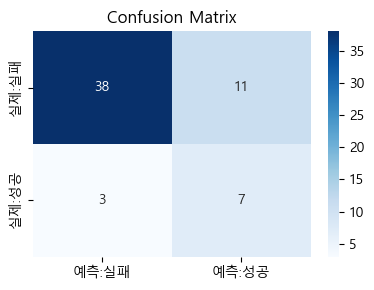


⚠️  위 수치는 훈련 데이터 기준입니다. 실제 일반화 성능은 교차검증 AUC를 참고하세요.


In [107]:
from sklearn.metrics import confusion_matrix, classification_report

# 훈련 데이터 기준 예측 (참고용 — 실제 일반화 성능은 위 AUC 기준)
y_pred = lr_model.predict(X_bana)

# 혼동 행렬
cm = confusion_matrix(y_bana, y_pred)
tn, fp, fn, tp = cm.ravel()

# 정확도 · 특이도 계산
accuracy    = (tp + tn) / (tp + tn + fp + fn)
specificity = tn / (tn + fp)   # 실패 매장을 실패로 맞춘 비율
sensitivity = tp / (tp + fn)   # 성공 매장을 성공으로 맞춘 비율 (재현율)

print(f'정확도  (Accuracy)   : {accuracy:.3f}')
print(f'특이도  (Specificity): {specificity:.3f}  ← 실패 매장을 실패로 맞춘 비율')
print(f'민감도  (Sensitivity): {sensitivity:.3f}  ← 성공 매장을 성공으로 맞춘 비율')

# 분류 리포트
print('\n=== 분류 리포트 ===')
print(classification_report(y_bana, y_pred, target_names=['실패(0)', '성공(1)']))

# 혼동 행렬 시각화
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측:실패', '예측:성공'],
            yticklabels=['실제:실패', '실제:성공'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print('\n⚠️  위 수치는 훈련 데이터 기준입니다. 실제 일반화 성능은 교차검증 AUC를 참고하세요.')

### 7.3 교차 검증 결과 해석

- AUC(ROC) 약 0.767 → 성공 매장과 실패 매장을 약 76.7% 확률로 구분 가능

| 지표 | 설명 |
|------|------|
| **정확도 (Accuracy)** | 전체 중 맞게 예측한 비율 = (TP+TN) / 전체 |
| **특이도 (Specificity)** | 실제 실패 매장을 실패로 맞춘 비율 = TN / (TN+FP) |
| **민감도 (Sensitivity)** | 실제 성공 매장을 성공으로 맞춘 비율 = TP / (TP+FN) |

> ⚠️ 훈련 데이터(59개)로 바로 예측한 수치라 실제보다 높게 나올 수 있습니다.  
> 신뢰할 수 있는 일반화 성능은 **교차검증 AUC 0.767** 기준으로 판단하세요.


### 7.4 시각화 (LR 계수)

Logistic Regression의 계수(coef_)는 각 피처가 성공에 기여하는 방향과 크기를 나타냄.  


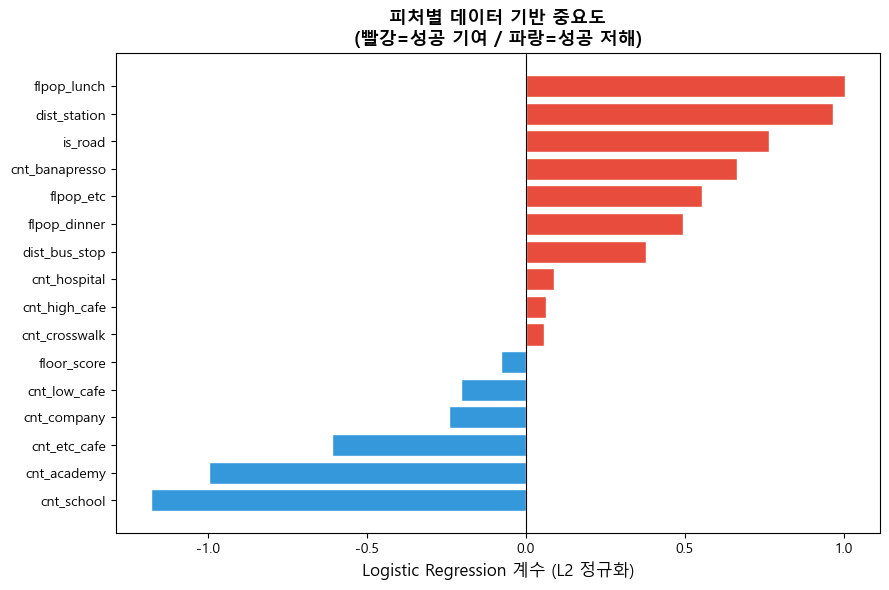


[도메인 가중치 vs 데이터 기반 계수 비교]


,도메인_가중치,LR_계수
flpop_lunch,0.14,1.005046
dist_station,0.08,0.965979
is_road,0.09,0.763401
cnt_banapresso,0.08,0.662726
flpop_etc,0.10,0.553086
flpop_dinner,0.14,0.494942
dist_bus_stop,0.07,0.376343
cnt_hospital,0.02,0.088542
cnt_high_cafe,0.05,0.063714
cnt_crosswalk,0.03,0.057529


In [108]:
coef = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression 계수 (L2 정규화)', fontsize=12)
ax.set_title('피처별 데이터 기반 중요도\n(빨강=성공 기여 / 파랑=성공 저해)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[도메인 가중치 vs 데이터 기반 계수 비교]')
compare = pd.DataFrame({
    '도메인_가중치': pd.Series(weights),
    'LR_계수':      coef
}).sort_values('LR_계수', ascending=False)
compare

### 7.5 도메인 가중치 vs LR 계수 비교 해석

도메인 기반 가중치와 Logistic Regression이 학습한 계수를 비교하여 입지 요인의 중요도를 검증하였다.

분석 결과 역세권 접근성과 점심 시간 유동인구가 성공 매장의 주요 특징으로 나타났으며,

일부 변수(학교·학원)는 도메인 가설과 다른 패턴을 보였다. 

아마 학원 많은 곳은 경쟁 저가 카페가 많기 때문인듯

## 8. 매물 성공 확률 예측 & 추천


도메인 점수(기본 입지 기준 미달 매물 제거) -> Logistic Regression (검증한 성공 가능성 순서로 최종 추천)

### 8.1 도메인 점수 계산

공동 스케일링된 listing feature에 가중치 적용.

bana_df도 동일 스케일로 재계산해 기준선(성공 매장 평균)으로 활용.

In [109]:
# LR 스케일 기준 입지 점수 → location_score_lr (별도 컬럼, rule-based 점수를 덮어쓰지 않음)
listing_scaled_df = pd.DataFrame(X_listing, columns=feature_cols,
                                  index=listing_df.index)

listing_df['location_score_lr'] = listing_scaled_df.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

# bana_df도 동일 스케일로 재계산 (검증용)
bana_scaled_df = pd.DataFrame(X_bana, columns=feature_cols, index=bana_df.index)
bana_df['location_score_v2'] = bana_scaled_df.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

print('매물 LR 기반 입지 점수 분포')
print(listing_df['location_score_lr'].describe().round(3))
bana_avg = bana_df[bana_df['success']==1]['location_score_v2'].mean()
print(f'\n성공 매장 평균 (LR 스케일): {bana_avg:.3f}')

# rule-based location_score 그대로 유지 확인
print(f'\nrule-based location_score 최대: {listing_df["location_score"].max():.4f}')


매물 LR 기반 입지 점수 분포
count    1316.000
mean        0.418
std         0.070
min         0.234
25%         0.360
50%         0.417
75%         0.470
max         0.596
Name: location_score_lr, dtype: float64

성공 매장 평균 (LR 스케일): 0.503

rule-based location_score 최대: 0.9619


### 8.2 성공 확률 예측

`predict_proba()[:, 1]` = 해당 매물에 바나프레소가 입점했을 때 3년 이상 생존할 확률


In [110]:
listing_df['success_prob'] = lr_model.predict_proba(X_listing)[:, 1]

# ── 최종 추천 점수: rule-based recom_score(75점) + success_prob 보정(25점) ──
# recom_score는 location_score(floor_score 포함) * 75 + cost_score(25점)
# success_prob는 LR이 판단한 성공 가능성 → 추가 보정 점수로 활용
listing_df['final_score'] = (
    listing_df['recom_score'] * 0.7        # rule-based (floor_score 반영)
    + listing_df['success_prob'] * 100 * 0.3  # LR 성공확률 보정
)

print('매물 성공 확률 분포')
print(listing_df['success_prob'].describe().round(3))
print('\n최종 추천 점수(final_score) 분포')
print(listing_df['final_score'].describe().round(3))


매물 성공 확률 분포
count    1316.000
mean        0.502
std         0.133
min         0.183
25%         0.407
50%         0.509
75%         0.597
max         0.821
Name: success_prob, dtype: float64

최종 추천 점수(final_score) 분포
count    1316.000
mean       68.366
std        10.300
min        33.349
25%        61.772
50%        69.808
75%        76.146
max        89.057
Name: final_score, dtype: float64


### 8.3 TOP 20 추천

- location_score로 상위 50% 
- success_prob로 내림차순 정렬 → TOP 20

In [111]:
# recom_score 상위 50% 필터 (rule-based, floor_score 반영된 점수 기준)
threshold = listing_df['recom_score'].median()
candidates = listing_df[listing_df['recom_score'] >= threshold].copy()
print(f'recom_score 필터 후 후보: {len(candidates):,}건 (전체 {len(listing_df):,}건 중)')

show_cols = ['listing_id','addr','floor',
             'deposit_만원','monthly_rent_만원','size_평',
             'flpop_lunch','flpop_dinner',
             'dist_station','cnt_crosswalk','is_road',
             'cost_score','location_score','success_prob','final_score']
show_cols = [c for c in show_cols if c in candidates.columns]

# final_score 기준 TOP 20 (rule-based + LR 성공확률 통합)
top20 = candidates.nlargest(20, 'final_score')[show_cols].copy().reset_index(drop=True)
top20.index += 1

fmt = {'deposit_만원':'{:,.0f}만'.format, 'monthly_rent_만원':'{:,.0f}만'.format,
       'flpop_lunch':'{:,.0f}'.format,   'flpop_dinner':'{:,.0f}'.format,
       'dist_station':'{:.0f}m'.format,
       'cost_score':'{:.2f}'.format,
       'location_score':'{:.4f}'.format,
       'success_prob':'{:.4f}'.format,
       'final_score':'{:.4f}'.format}
for col, fn in fmt.items():
    if col in top20.columns:
        top20[col] = top20[col].map(fn)

print('\n바나프레소 입지 추천 TOP 20 (rule-based + LR 통합)')
top20


recom_score 필터 후 후보: 659건 (전체 1,316건 중)

바나프레소 입지 추천 TOP 20 (rule-based + LR 통합)


,listing_id,addr,floor,deposit_만원,monthly_rent_만원,size_평,flpop_lunch,flpop_dinner,dist_station,cnt_crosswalk,is_road,cost_score,location_score,success_prob,final_score
1,921771,서울특별시 강남구 논현동,1.0,"1,100만",110만,17.8,"388,874","478,718",211m,13,1,24.89,0.9387,0.7452,89.0567
2,419277,서울특별시 강남구 논현동,1.0,"3,000만",230만,16.0,"388,874","478,718",58m,16,1,24.75,0.9313,0.7597,89.0123
3,891481,서울특별시 서초구 잠원동,1.0,"2,000만",170만,17.0,"388,874","478,718",171m,16,1,24.77,0.9473,0.7313,89.0095
4,921586,서울특별시 서초구 잠원동,1.0,"2,000만",170만,17.1,"388,874","478,718",171m,16,1,24.77,0.9473,0.7313,89.0095
5,881607,서울특별시 서초구 잠원동,1.0,"7,000만",600만,62.0,"388,874","478,718",251m,15,1,23.97,0.9592,0.7094,88.4210
6,878448,서울특별시 강남구 논현동,1.0,"4,000만",210만,6.0,"388,874","478,718",187m,10,1,24.16,0.9364,0.7443,88.4001
7,921387,서울특별시 강남구 역삼동,2.0,"3,000만",290만,39.6,"589,152","788,268",397m,4,1,24.75,0.9252,0.7452,88.2545
8,808105,서울특별시 강남구 논현동,1.0,"3,000만",230만,9.0,"378,147","391,751",242m,11,1,24.72,0.9493,0.6970,88.0553
9,882189,서울특별시 강남구 논현동,1.0,"3,000만",265만,10.0,"378,147","391,751",242m,11,1,24.68,0.9493,0.6970,88.0275
10,908913,서울특별시 강남구 논현동,1.0,"5,500만",490만,42.9,"568,765","648,546",153m,17,1,24.49,0.9427,0.7120,87.9919


## 9. 지도 시각화


In [112]:
m = folium.Map(location=[37.545, 127.0], zoom_start=11, tiles='cartoDBpositron')

layer_success = folium.FeatureGroup(name='바나프레소 성공 매장', show=True)
layer_fail    = folium.FeatureGroup(name='바나프레소 신규/실패',         show=True)
layer_listing = folium.FeatureGroup(name='추천 매물 TOP 50',            show=True)

for _, row in bana_df.iterrows():
    is_ok = row['success'] == 1
    score = row.get('location_score_v2', row.get('location_score', 0))
    popup = (
        f"<b>{row['nm']}</b><br>"
        f"개점일: {str(row['apv_date'])[:10]}<br>"
        f"입지점수: {score:.3f}<br>"
        f"{'성공' if is_ok else '신규/실패'}"
    )
    folium.Marker(
        [row['lat'], row['lng']],
        icon=folium.Icon(color="pink" if is_ok else "lightgray",
                         icon='star' if is_ok else 'times', prefix='fa'),
        popup=folium.Popup(popup, max_width=230)
    ).add_to(layer_success if is_ok else layer_fail)

# 추천 매물: 후보 중 success_prob 상위 50개
top50 = candidates.nlargest(50, 'final_score').reset_index(drop=True)
top50['rank'] = top50.index + 1

def rank_color(r): return 'red' if r<=10 else ('orange' if r<=30 else 'green')

cluster = MarkerCluster().add_to(layer_listing)
for _, row in top50.iterrows():
    rk   = int(row['rank'])
    dep  = row.get('deposit_만원',      row.get('deposit', 0) / 10_000)
    rent = row.get('monthly_rent_만원', row.get('monthly_rent', 0) / 10_000)
    size = row.get('size_평',           row.get('size_m2', 0) / 3.3058)
    popup = (
        f"<b>{rk}위 추천 매물</b><br>"
        f"위치 : {row.get('addr','')}<br>"
        f"{row.get('floor','')}  {size:.1f}평<br><hr>"
        f"보증금: {dep:,.0f}만원 / 월세: {rent:,.0f}만원<br><hr>"
        f"🚶 점심유동인구: {row.get('flpop_lunch',0):,.0f}<br>"
        f"🚶 저녁유동인구: {row.get('flpop_dinner',0):,.0f}<br>"
        f"🚇 지하철접근성: {row.get('dist_station',0):.0f}m<br>"
        f"🛣 대로변접근성: {'근접' if row.get('is_road',0)==1 else '원격'}<br><hr>"
        f"입지점수: <b>{row.get('location_score',0):.4f}</b><br>"
        f"성공확률: <b>{row.get('success_prob',0):.4f}</b>"
    )
    folium.Marker(
        [row['lat'], row['lng']],
        icon=folium.Icon(color=rank_color(rk), icon='home', prefix='fa'),
        popup=folium.Popup(popup, max_width=270)
    ).add_to(cluster)

layer_success.add_to(m)
layer_fail.add_to(m)
layer_listing.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

legend = """
<div style='position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:12px 16px;border-radius:8px;border:2px solid #aaa;
            font-size:13px;line-height:1.9;box-shadow:2px 2px 6px rgba(0,0,0,.2)'>
  <b>범례</b><br>
  <span style='color:steelblue'>★</span> 바나프레소 성공<br>
  <span style='color:crimson'>✕</span> 바나프레소 신규/실패<br>
  <span style='color:crimson'>⌂</span> 추천 TOP 1~10<br>
  <span style='color:darkorange'>⌂</span> 추천 TOP 11~30<br>
  <span style='color:green'>⌂</span> 추천 TOP 31~50
</div>"""
m.get_root().html.add_child(folium.Element(legend))

m.save('banaresso_map.html')
print('저장 완료 → banaresso_map.html')
m

저장 완료 → banaresso_map.html


## 10. 결과 저장


In [118]:
save_cols = [
    'listing_id','addr','lat','lng','floor',
    'deposit_만원','monthly_rent_만원','size_평',
    'flpop_lunch','flpop_dinner','flpop_etc',
    'dist_station','dist_bus_stop','cnt_crosswalk','is_road',
    'cnt_academy','cnt_hospital','cnt_school','cnt_company',
    'cnt_banapresso','cnt_high_cafe','cnt_low_cafe','cnt_etc_cafe',
    'rent_score','capital_score','cost_score',
    'location_score','location_score_lr','success_prob',
    'recom_score','final_score'
]
# 실제로 존재하는 컬럼만 저장
save_cols = [c for c in save_cols if c in listing_df.columns]

out = (listing_df[save_cols]
       .sort_values('final_score', ascending=False)
       .reset_index(drop=True))
out.index += 1
out.to_csv('listing_scored_ml.csv', index_label='rank', encoding='utf-8-sig')

print(f'저장 완료: listing_scored_ml.csv ({len(out):,}건)')
out[['addr','floor','deposit_만원','monthly_rent_만원',
     'cost_score','location_score','success_prob','final_score']].head(10)


저장 완료: listing_scored_ml.csv (1,316건)


,addr,floor,deposit_만원,monthly_rent_만원,cost_score,location_score,success_prob,final_score
1,서울특별시 강남구 논현동,1.0,1100.0,110.0,24.885057,0.938696,0.745188,89.056733
2,서울특별시 강남구 논현동,1.0,3000.0,230.0,24.749216,0.931347,0.759739,89.012337
3,서울특별시 서초구 잠원동,1.0,2000.0,170.0,24.769464,0.947261,0.731322,89.009479
4,서울특별시 서초구 잠원동,1.0,2000.0,170.0,24.769464,0.947261,0.731322,89.009479
5,서울특별시 서초구 잠원동,1.0,7000.0,600.0,23.974613,0.959166,0.709418,88.420988
6,서울특별시 강남구 논현동,1.0,4000.0,210.0,24.156255,0.936400,0.744324,88.400094
7,서울특별시 강남구 역삼동,2.0,3000.0,290.0,24.748239,0.925212,0.745238,88.254515
8,서울특별시 강남구 논현동,1.0,3000.0,230.0,24.722324,0.949310,0.697031,88.055298
9,서울특별시 강남구 논현동,1.0,3000.0,265.0,24.682656,0.949310,0.697031,88.027531
10,서울특별시 강남구 논현동,1.0,5500.0,490.0,24.487983,0.942690,0.711968,87.991869


# LLM (Openai api)

In [114]:
!pip install openai

In [ ]:
from openai import OpenAI
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv("E:/web_prj/Brewmap_api/Brewmap/.env", override=True)

class PropertyRecommender:
    def __init__(self):
        self.client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    
    def get_top3(self, df_rule, df_ml):
        top3 = df_rule.nlargest(3, 'recom_score').reset_index(drop=True)
    
        top3 = top3.merge(
            df_ml[['listing_id', 'final_score', 'location_score', 'cost_score']].rename(columns={
                'final_score':    'ml_final_score',
                'location_score': 'ml_location_score',
                'cost_score':     'ml_cost_score'
            }),
            on='listing_id',  # ✅ listing_id 기준으로 변경
            how='left'
        )
    

        return top3
    
    def make_property_info(self, top3_df):
        info = ""
        for i, prop in top3_df.iterrows():
            ml_final    = f"{prop['ml_final_score']:.4f}"    if pd.notna(prop.get('ml_final_score'))    else "데이터 없음"
            ml_location = f"{prop['ml_location_score']:.4f}" if pd.notna(prop.get('ml_location_score')) else "데이터 없음"
            ml_cost     = f"{prop['ml_cost_score']:.4f}"     if pd.notna(prop.get('ml_cost_score'))     else "데이터 없음"

            info += f"""
[매물 {i+1}]
- listing_id: {prop['listing_id']}
- 주소: {prop['addr']} {prop['floor']}
- 월세: {prop['monthly_rent']}만원
- 면적: {prop['size_m2']}㎡
- 점심 유동인구: {prop['flpop_lunch']:.0f}명
- 저녁 유동인구: {prop['flpop_dinner']:.0f}명
- 지하철 거리: {prop['dist_station']:.0f}m
- 버스 거리: {prop['dist_bus_stop']:.0f}m
- 횡단보도 수: {prop['cnt_crosswalk']}개
- 주변 학교 수: {prop['cnt_school']}개
- 주변 병원 수: {prop['cnt_hospital']}개
- 주변 학원 수: {prop['cnt_academy']}개
- 바나프레소 수: {prop['cnt_banapresso']}개
- 저가카페 수: {prop['cnt_low_cafe']}개
- 고가카페 수: {prop['cnt_high_cafe']}개

  [Rule 기반 점수 - 주요 지표]
  - 입지점수: {prop['location_score']:.4f}
  - 비용점수: {prop['cost_score']:.4f}
  - 최종점수: {prop['recom_score']:.4f}

  [ML 기반 점수 - 보조 지표]
  - 입지점수: {ml_location}
  - 비용점수: {ml_cost}
  - 최종점수: {ml_final}
"""
        return info
    
    def explain(self, df_rule, df_ml):
        top3 = self.get_top3(df_rule, df_ml)
        property_info = self.make_property_info(top3)
        
        prompt = f"""
바나프레소 신규 매장 오픈을 위한 서울 매물 Top-3를 분석해주세요.

[점수 체계]
- Rule 기반 점수(주요 지표): 전문가 규칙으로 산출한 신뢰도 높은 점수. 분석의 주된 근거로 사용하세요.
- ML 기반 점수(보조 지표): 머신러닝으로 산출한 점수. Rule 점수와 방향이 일치하면 신뢰도 보강, 불일치하면 주의 신호로 해석하세요.

[분석 기준]
- 입지점수: 유동인구, 대중교통 접근성, 주변 시설 수
- 비용점수: 월세 부담 (낮을수록 유리)
- 최종점수: 입지 + 비용 종합

[Top-3 매물 정보]
{property_info}

[출력 형식 - 반드시 아래 형식만 사용]
1️⃣ 1위 매물 - [주소] (listing_id: [listing_id])
- 추천 이유: (Rule 점수 근거 중심, 데이터 수치 명시)
- ML 보조 지표 해석: (Rule 점수와 일치/불일치 여부 및 의미)
- 주의사항: (경쟁 카페 수, 월세 부담 등 데이터 수치 근거로만 작성)

2️⃣ 2위 매물 - [주소] (listing_id: [listing_id])
- 추천 이유:
- ML 보조 지표 해석:
- 주의사항:

3️⃣ 3위 매물 - [주소] (listing_id: [listing_id])
- 추천 이유:
- ML 보조 지표 해석:
- 주의사항:

✅ 최종 추천 및 종합 의견: (Rule 점수 기준으로 결론, ML 점수로 보강 또는 주의사항 언급)

[절대 포함하지 말 것]
- 메뉴, 마케팅, 인테리어, 운영 전략 관련 언급
- 매출 예측 또는 수익성 추정
- 제공된 데이터 외 추측성 조언
"""
        
        response = self.client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "당신은 카페 입지 분석 전문가입니다. 반드시 한국어로만 답변하세요. "
                        "Rule 기반 점수를 주요 근거로, ML 기반 점수를 보조 지표로 활용하여 분석하세요. "
                        "오직 제공된 수치 데이터만을 근거로 분석하며, "
                        "메뉴, 마케팅, 인테리어, 매출 예측 등 데이터 범위 밖의 조언은 절대 하지 마세요."
                    )
                },
                {"role": "user", "content": prompt}
            ],
            max_tokens=5000
        )
        
        return top3, response.choices[0].message.content


# 실행
if __name__ == "__main__":
    df_ml   = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/listing_scored_ml.csv",   encoding="utf-8-sig")
    df_rule = pd.read_csv("E:/web_prj/Brewmap_api/Brewmap/dataAnal/data/listing_scored_rule.csv", encoding="utf-8-sig")
    
    # ✅ 월세 0 또는 결측치 제거
    df_rule = df_rule[df_rule['monthly_rent'] > 0].reset_index(drop=True)
    
    recommender = PropertyRecommender()
    top3, explanation = recommender.explain(df_rule, df_ml)
    
    
    print("\n=== LLM 입지 분석 결과 ===")
    print(explanation)


=== LLM 입지 분석 결과 ===
1️⃣ 1위 매물 - [서울특별시 서초구 반포동 1] (listing_id: 926093)  
- 추천 이유: 입지점수 0.9669은 매우 높은 유동인구(점심 388874명, 저녁 478718명)와 대중교통 접근성(지하철 306m, 버스 73m)을 고려했을 때 신뢰할 수 있는 수치입니다. 월세는 800000원으로 저렴하여 비용점수도 24.9250으로 양호합니다. 최종점수는 97.4402로 우수합니다.  
- ML 보조 지표 해석: ML 기반 입지점수 0.8773은 Rule 점수와 유사하여 신뢰성을 보강합니다. 그러나 최종점수 79.1816은 다소 낮아 주의가 필요합니다.  
- 주의사항: 경쟁 카페 수는 저가 4개, 고가 4개로 존재하며, 주변 학원 및 학교가 없어 고객 유입에 부정적 영향을 미칠 수 있습니다. 

2️⃣ 2위 매물 - [서울특별시 서초구 반포동 1] (listing_id: 539198)  
- 추천 이유: 입지점수 0.9622으로 상대적으로 높은 유동인구(점심 388874명, 저녁 478718명)를 갖고 있으며, 대중교통 접근성도 우수합니다(지하철 230m, 버스 80m). 월세는 1850000원으로 비교적 부담이 있으며, 비용점수는 24.8265입니다. 최종점수는 96.9924로 적정 수준입니다.  
- ML 보조 지표 해석: ML 기반 점수에서도 입지점수 0.8767이 Rule 점수와 근접하여 긍정적이나, 최종점수는 84.9430으로 상대적으로 낮아 주의가 필요합니다.  
- 주의사항: 저가 카페가 3개, 고가 카페가 2개 존재하여 경쟁이 존재하며, 월세 부담이 상대적으로 큽니다.

3️⃣ 3위 매물 - [서울특별시 강남구 논현동 1] (listing_id: 393421)  
- 추천 이유: 입지점수 0.9590으로 유동인구가 많습니다(점심 589152명, 저녁 788268명). 월세는 2000000원으로 가장 비쌉니다. 비용점수는 24.7910입니다. 최종점수는 96.7151로 경합 매물들 중 양호

## 10. 회고

- 학습 데이터 규모가 매우 제한적(59개)이었기 때문에 모델이 성공 패턴을 안정적으로 일반화하기에는 한계가 있었다. 향후에는 바나프레소뿐 아니라 유사 중가 커피 프랜차이즈 데이터를 포함하여 학습 데이터를 수백~수천 건 규모로 확장한다면 모델의 일반화 성능을 개선할 수 있을 것으로 보인다.

- 제한된 데이터 환경을 고려하여 정확한 예측 모델 구축보다는 상권·입지 특성을 정량화하고 매물 추천 구조를 설계하는 데 분석의 초점을 두었다. 이를 통해 유동인구, 접근성, 주변시설, 경쟁 카페 등의 요소를 기반으로 입지 점수를 계산하고, 머신러닝 모델을 활용해 성공 가능성이 높은 매물을 선별하는 추천 구조를 구현하였다.

